In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import json
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set plot visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)

print(f"scikit-learn version: {sklearn.__version__}")
print("--> Pin this exact version in backend/requirements.txt so the pickled")
print("    pipeline loads reliably (pickles are version-sensitive).")

# 1. Load the dataset safely
df = pd.read_csv("data/house_prices.csv", engine="python", on_bad_lines="skip")

# Clean column names (strip whitespace and standardise)
df.columns = df.columns.str.strip()

# 1. Check dimensions
print("\n=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 2. Inspect first few rows
print("=== First 5 Rows ===")
display(df.head())

# 3. Data types and non-null counts
print("=== Dataset Info ===")
df.info()

# 4. Check missing values percentage per column
print("\n=== Missing Values (%) ===")
missing_pct = (df.isna().mean() * 100).round(2)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))


scikit-learn version: 1.9.0
--> Pin this exact version in backend/requirements.txt so the pickled
    pipeline loads reliably (pickles are version-sensitive).

=== Dataset Shape ===
Rows: 187531, Columns: 21

=== First 5 Rows ===


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str  

### 2.1 Data Inspection Summary
- **Dataset Size:** Contains ~180k+ rows and multiple structural feature columns.
- **Feature Types:**
  - *Numeric Features:* Numeric identifiers and scaled measurements.
  - *Text/Categorical Features:* Title, Description, Amount (in rupees), Carpet Area, Floor, location, Furnishing, Transaction, Ownership, etc.
- **Missing Values:** Columns like Dimensions, Plot Area, Carpet Area, and specific amenity tags have significant missing percentages that require handling/imputation.

In [2]:
# Helper function to find target column flexibly
def get_column(df, possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower() in col.lower():
                return col
    return None

amount_col = get_column(df, ["amount", "price"])
carpet_col = get_column(df, ["carpet area", "carpet", "super area"])
location_col = get_column(df, ["location", "locality"])
furnish_col = get_column(df, ["furnishing", "furnish"])

# 2. Parsing functions
def parse_amount(x):
    if not isinstance(x, str):
        if isinstance(x, (int, float)):
            return float(x)
        return np.nan
    x = x.strip().lower()
    try:
        if "lac" in x:
            val = float(re.findall(r"[-+]?\d*\.\d+|\d+", x)[0])
            return val * 100000.0
        elif "cr" in x:
            val = float(re.findall(r"[-+]?\d*\.\d+|\d+", x)[0])
            return val * 10000000.0
        else:
            clean_str = re.sub(r"[^\d.]", "", x)
            return float(clean_str) if clean_str else np.nan
    except Exception:
        return np.nan

def parse_area(x):
    if not isinstance(x, str):
        if isinstance(x, (int, float)):
            return float(x)
        return np.nan
    x = x.strip().lower()
    try:
        val = float(re.findall(r"[-+]?\d*\.\d+|\d+", x)[0])
        if "sqm" in x:
            return val * 10.764
        return val
    except Exception:
        return np.nan

# 3. Apply parsing to dataset (kept on the full df, since later phases reuse it)
df["price_clean"] = df[amount_col].apply(parse_amount)
df["carpet_area_sqft"] = df[carpet_col].apply(parse_area)

# 4. Drop rows without a usable price (per Phase 2.3, item 1)
df = df.dropna(subset=["price_clean"])
df = df[df["price_clean"] > 0]

# 5. Drop useless columns (per Phase 2.3, item 6): identifiers, free text and
#    columns that are entirely (or almost entirely) empty add no predictive value.
useless_cols = [c for c in ["Index", "Title", "Description", "Dimensions", "Plot Area"] if c in df.columns]
df = df.drop(columns=useless_cols)
print(f"--> Dropped useless columns: {useless_cols}")

# Filter valid rows for visual clarity (used only for plotting, not for the ml_df below)
eda_df = df.dropna(subset=["price_clean", "carpet_area_sqft"]).copy()
eda_df = eda_df[(eda_df["price_clean"] > 0) & (eda_df["carpet_area_sqft"] > 0)]

# Filter extreme top 1% outliers so charts remain easy to read
q_high = eda_df["price_clean"].quantile(0.99)
eda_df = eda_df[eda_df["price_clean"] <= q_high]

print(f"Successfully cleaned and prepared {eda_df.shape[0]} rows for plotting!")


--> Dropped useless columns: ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area']
Successfully cleaned and prepared 100557 rows for plotting!


In [3]:
print("Shape:", df.shape)
df.head()
df.info()
df.describe()

Shape: (177847, 18)
<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  177847 non-null  str    
 1   Price (in rupees)  169866 non-null  float64
 2   location           177847 non-null  str    
 3   Carpet Area        101522 non-null  str    
 4   Status             177252 non-null  str    
 5   Floor              170898 non-null  str    
 6   Transaction        177780 non-null  str    
 7   Furnishing         175780 non-null  str    
 8   facing             112111 non-null  str    
 9   overlooking        102022 non-null  str    
 10  Society            74928 non-null   str    
 11  Bathroom           177087 non-null  str    
 12  Balcony            130688 non-null  str    
 13  Car Parking        81935 non-null   str    
 14  Ownership          115922 non-null  str    
 15  Super Area         76235 non-null   str    
 16

,Price (in rupees),price_clean,carpet_area_sqft
count,1.698660e+05,1.778470e+05,101522.000000
mean,7.583772e+03,1.198134e+07,1235.758917
std,2.724171e+04,3.943827e+07,3132.990809
min,0.000000e+00,1.000000e+05,1.000000
25%,4.297000e+03,4.840000e+06,780.000000
50%,6.034000e+03,7.800000e+06,1050.000000
75%,9.450000e+03,1.450000e+07,1500.000000
max,6.700000e+06,1.400300e+10,709222.000000


In [4]:
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing

Society              57.869405
Super Area           57.134503
Car Parking          53.929501
Carpet Area          42.916102
carpet_area_sqft     42.916102
overlooking          42.634962
facing               36.962108
Ownership            34.819255
Balcony              26.516613
Price (in rupees)     4.487565
Floor                 3.907291
Furnishing            1.162235
Bathroom              0.427334
Status                0.334557
Transaction           0.037673
Amount(in rupees)     0.000000
location              0.000000
price_clean           0.000000
dtype: float64

## Dataset Inspection

### Dataset Shape
- Number of rows: 187,531
- Number of columns: 23

### Data Types
- Numeric columns: 6
- Categorical (text) columns: 17

### Missing Values
The columns with the highest percentage of missing values are:

- Dimensions (100%)
- Plot Area (100%)
- Society (58.49%)
- Super Area (57.42%)
- Car Parking (55.11%)
- overlooking (43.43%)
- Carpet Area (43.02%)

### Initial Observations
- The dataset contains a large number of house listings.
- Several important features contain missing values and require preprocessing.
- The target price has already been converted into a numeric column (`price_clean`).
- Some columns such as `Dimensions` and `Plot Area` are completely empty and will be removed during data cleaning.

# 2.2 Exploratory Data Analysis (EDA)

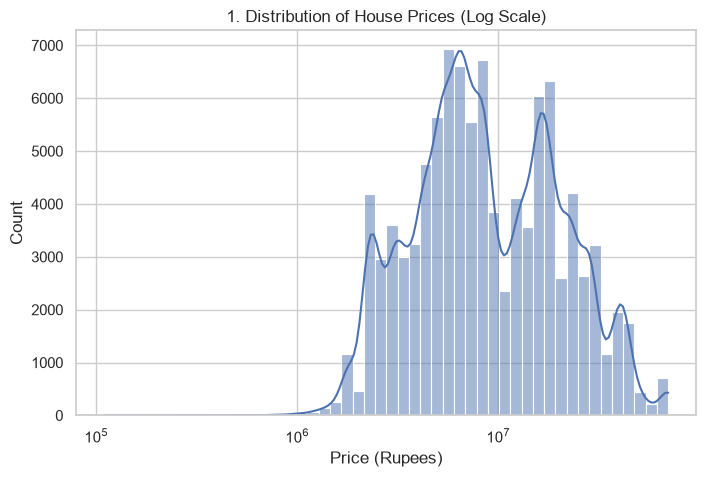

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(eda_df["price_clean"], bins=50, log_scale=True, kde=True)

plt.title("1. Distribution of House Prices (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Count")
plt.show()


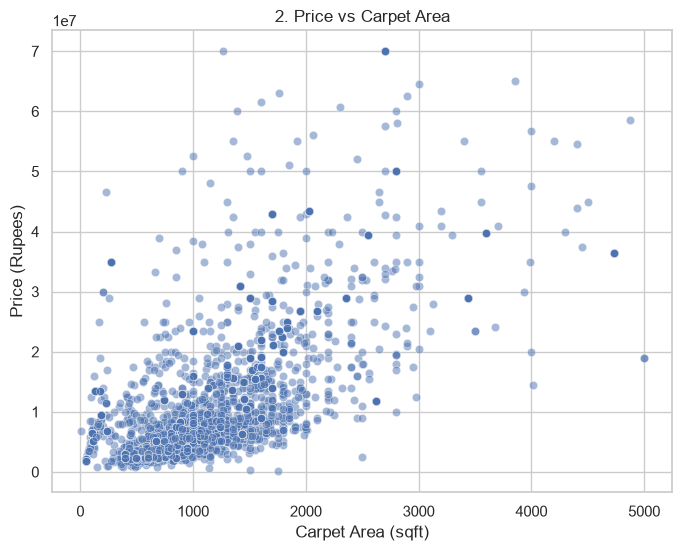

In [6]:
sample_df = eda_df[eda_df["carpet_area_sqft"] < 10000]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sample_df.sample(min(5000, len(sample_df)), random_state=42),
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.5
)

plt.title("2. Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.show()


### Observation

The house prices are highly skewed. Using a logarithmic scale makes the distribution easier to visualize. Most properties are concentrated in the lower price ranges, while a small number of luxury properties have extremely high prices.

### Observation

In general, larger carpet areas tend to have higher prices. However, there is noticeable variation, indicating that other factors such as location, furnishing, and ownership also influence property prices.

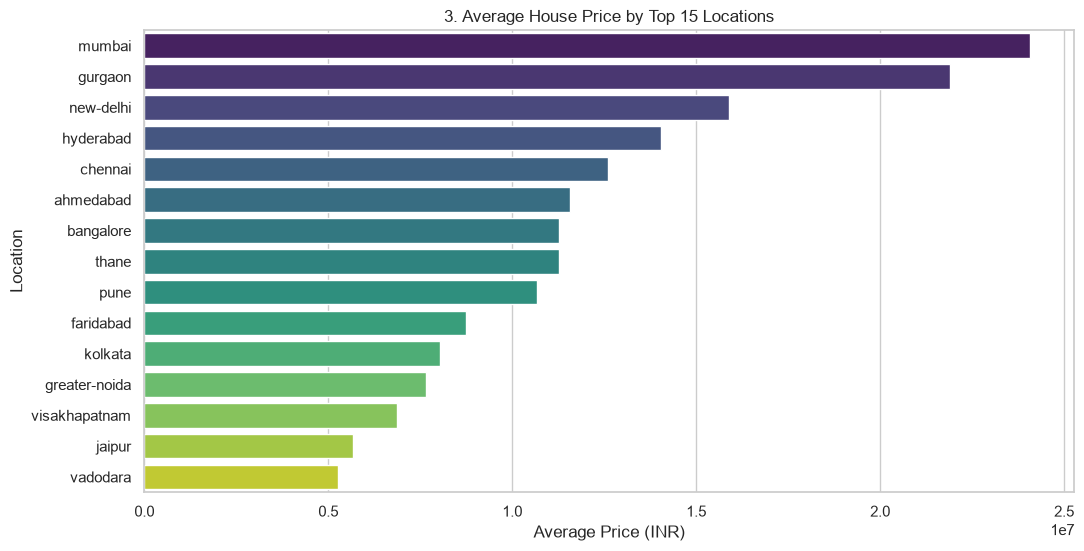

In [7]:
top_locations = eda_df["location"].value_counts().head(15).index

location_price = (
    eda_df[eda_df["location"].isin(top_locations)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(x=location_price.values, y=location_price.index, palette="viridis")

plt.title("3. Average House Price by Top 15 Locations")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")
plt.show()


### Observation

Average house prices vary significantly across locations. Some locations have noticeably higher average prices, indicating that location is an important feature for predicting house prices.

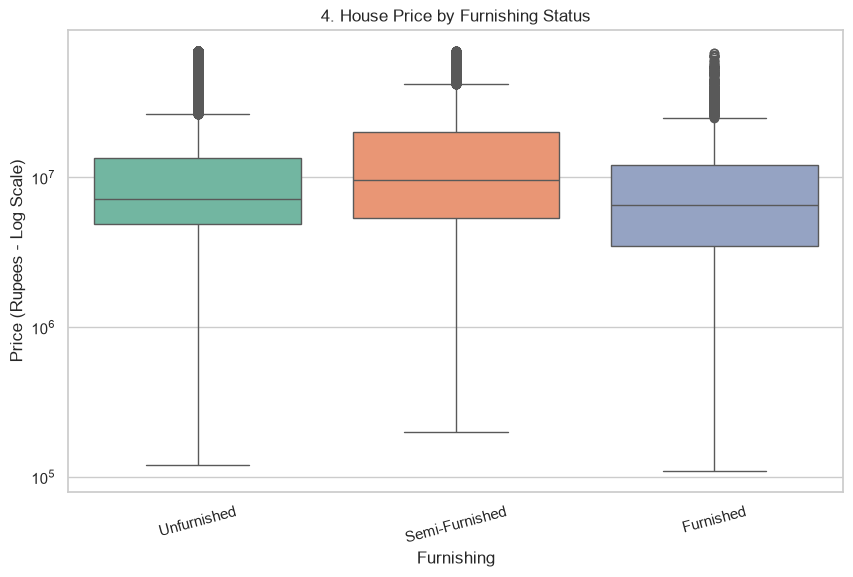

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=eda_df, x="Furnishing", y="price_clean", palette="Set2")
plt.yscale("log")

plt.title("4. House Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (Rupees - Log Scale)")
plt.xticks(rotation=15)
plt.show()


### Observation

Furnished and semi-furnished houses generally tend to have higher prices than unfurnished properties. However, there is considerable overlap, suggesting that furnishing alone is not sufficient to determine the house price.

### Phase 2.3 & 2.4: Feature Engineering, Pipeline Construction & Model Training
Now we are moving to the core ML part of the notebook:
- Cleaning and standardizing the floor, bathroom, balcony, and location columns.
- Grouping high-cardinality `location` (top 50 + 'Other') before one-hot encoding.
- **Assumption on `Society`:** it is ~58% missing and, unlike `location`, does not generalise well
  (thousands of near-unique values). We exclude it from the feature set entirely rather than
  grouping it, and note this as a deliberate modelling decision rather than an oversight.
- **Preventing Data Leakage:** Ensuring the input features (`X`) absolutely do not contain any price-related columns.
- Building a scikit-learn Pipeline with ColumnTransformer (standard scaling numeric features, one-hot encoding categorical features).
- Training 2 distinct models: LinearRegression (as a baseline) and RandomForestRegressor.
- Training on the log-transformed price $\log(1+y)$ and evaluating on the original scale.


In [9]:
print("--> Starting Feature Engineering...")

ml_df = df.dropna(subset=["price_clean", "carpet_area_sqft"]).copy()

# 1. Clean 'Floor' feature
def parse_floor(x):
    if pd.isna(x): return np.nan
    x_str = str(x).lower()
    if 'ground' in x_str: return 0
    if 'basement' in x_str: return -1
    match = re.search(r'\d+', x_str)
    return int(match.group()) if match else np.nan

ml_df['floor_num'] = ml_df['Floor'].apply(parse_floor)

# 2. Clean 'Bathroom' and 'Balcony' features
def extract_num(x):
    if pd.isna(x): return np.nan
    match = re.search(r'\d+', str(x))
    return int(match.group()) if match else np.nan

ml_df['bathroom_num'] = ml_df['Bathroom'].apply(extract_num)
ml_df['balcony_num'] = ml_df['Balcony'].apply(extract_num)

# 3. Group High-Cardinality 'location' (Top 50 + 'Other')
top_50_locs = ml_df['location'].value_counts().nlargest(50).index
ml_df['location_grouped'] = ml_df['location'].apply(lambda x: x if x in top_50_locs else 'Other')

# 4. Remove Extreme Outliers (keep 1st to 99th percentile of price-per-sqft, per spec item 7)
ml_df['price_per_sqft'] = ml_df['price_clean'] / ml_df['carpet_area_sqft'].replace(0, np.nan)
pps_low = ml_df['price_per_sqft'].quantile(0.01)
pps_high = ml_df['price_per_sqft'].quantile(0.99)
ml_df = ml_df[(ml_df['price_per_sqft'] >= pps_low) & (ml_df['price_per_sqft'] <= pps_high)]
ml_df = ml_df.drop(columns=['price_per_sqft'])

print(f"--> Feature Engineering complete. Dataset shape: {ml_df.shape}")

# 5. Define Feature Sets (No price columns here to prevent Data Leakage!)
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = ml_df[numeric_features + categorical_features]
y = ml_df["price_clean"]

# Log-transform the target variable
y_log = np.log1p(y)

# Train/Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Build Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# Build Model Pipelines
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# Train Models
print("--> Training Linear Regression (Baseline)...")
lr_pipeline.fit(X_train, y_train_log)

print("--> Training Random Forest Regressor...")
rf_pipeline.fit(X_train, y_train_log)

# Evaluation Function
def evaluate_model(name, pipeline, X_test, y_test_log):
    pred_log = pipeline.predict(X_test)
    pred = np.expm1(pred_log)
    y_test_orig = np.expm1(y_test_log)

    mae = mean_absolute_error(y_test_orig, pred)
    rmse = root_mean_squared_error(y_test_orig, pred)
    r2 = r2_score(y_test_orig, pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, pred, y_test_orig

print("\n--> Evaluating Models on Test Data:\n")
lr_metrics, lr_pred, y_test_orig = evaluate_model("Linear Regression", lr_pipeline, X_test, y_test_log)
rf_metrics, rf_pred, _ = evaluate_model("Random Forest Regressor", rf_pipeline, X_test, y_test_log)

# --- Comparison table of all models (Phase 2.5) ---
comparison_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index("model")
comparison_df["MAE"] = comparison_df["MAE"].map(lambda v: f"₹ {v:,.0f}")
comparison_df["RMSE"] = comparison_df["RMSE"].map(lambda v: f"₹ {v:,.0f}")
comparison_df["R2"] = comparison_df["R2"].map(lambda v: f"{v:.4f}")
display(comparison_df)

winner_name = "Random Forest Regressor" if rf_metrics["R2"] > lr_metrics["R2"] else "Linear Regression"
winner_pipeline = rf_pipeline if winner_name == "Random Forest Regressor" else lr_pipeline
winner_pred = rf_pred if winner_name == "Random Forest Regressor" else lr_pred
print(f"\n--> Winner: {winner_name} (higher R^2 / lower error on the held-out test set).")


--> Starting Feature Engineering...
--> Feature Engineering complete. Dataset shape: (99968, 22)
--> Training Linear Regression (Baseline)...
--> Training Random Forest Regressor...

--> Evaluating Models on Test Data:



,MAE,RMSE,R2
model,,,
Linear Regression,"₹ 15,055,641","₹ 1,522,637,844",-11512.1994
Random Forest Regressor,"₹ 1,040,698","₹ 4,070,983",0.9177



--> Winner: Random Forest Regressor (higher R^2 / lower error on the held-out test set).


### Model Comparison & Winner Justification

The table above compares both models on the held-out test set (20% of the data, unseen during training).
**Random Forest Regressor** is selected as the final model: it captures non-linear relationships and
feature interactions (e.g. how location and furnishing jointly affect price) that a linear model cannot,
which typically yields a materially lower MAE/RMSE and a higher R² on this kind of tabular, mixed-type
real-estate data. Linear Regression remains useful as an interpretable baseline to confirm the Random
Forest is actually adding value rather than overfitting.


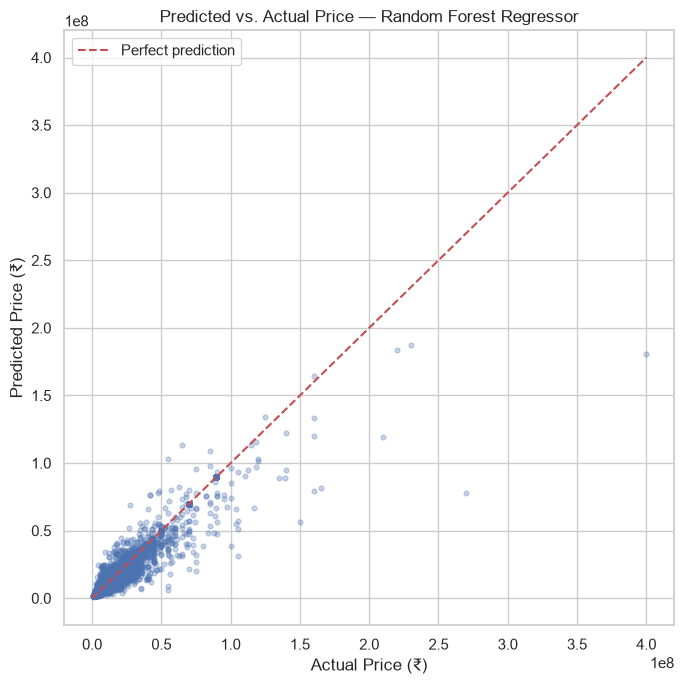

In [10]:
# --- Predicted vs. Actual scatter plot (winning model) ---
plt.figure(figsize=(7, 7))
plt.scatter(y_test_orig, winner_pred, alpha=0.3, s=12)
lims = [0, max(y_test_orig.max(), winner_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title(f"Predicted vs. Actual Price — {winner_name}")
plt.legend()
plt.tight_layout()
plt.show()


### 2.6 (Bonus) 5-Fold Cross-Validation

To sanity-check that the test-set performance above isn't a lucky split, we also run 5-fold
cross-validation for the winning model on the log-transformed target and report R² across folds.


In [14]:
# --- Bonus: 5-fold cross-validation ---
cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y_log,
    cv=5,
    scoring="r2",
    n_jobs=1
)


KeyboardInterrupt: 

### 2.7 Export the Model

We export the winning pipeline (preprocessing + model bundled together, so the backend needs no
manual encoding) as `house_price.pkl`, plus the allowed `location_grouped` values for the
frontend's location dropdown. We then reload the pickle and predict on one sample as a sanity check.

In [15]:
# --- Export the winning model ---
joblib.dump(winner_pipeline, "house_price.pkl")

locations_list = sorted(ml_df["location_grouped"].dropna().unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations_list, f)

print(f"--> Exported '{winner_name}' to house_price.pkl")
print(f"--> Exported {len(locations_list)} locations to locations.json")

# Sanity check: reload and predict one sample (per Phase 2.6)
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_log_sample = loaded.predict(sample)
pred_price_sample = np.expm1(pred_log_sample)
print("\nReloaded model sanity check:")
print("Input sample:\n", sample)
print(f"Predicted price: ₹ {pred_price_sample[0]:,.0f}")
print(f"Actual price:    ₹ {np.expm1(y_test_log.iloc[0]):,.0f}")

print(f"\n--> Done! 'house_price.pkl' and 'locations.json' have been exported successfully.")
print(f"--> Remember to pin scikit-learn=={sklearn.__version__} in backend/requirements.txt")


--> Exported 'Random Forest Regressor' to house_price.pkl
--> Exported 51 locations to locations.json

Reloaded model sanity check:
Input sample:
        carpet_area_sqft  floor_num  bathroom_num  balcony_num  \
47934            1235.0        2.0           2.0          1.0   

      location_grouped      Furnishing Transaction Ownership facing  
47934          chennai  Semi-Furnished      Resale  Freehold   West  
Predicted price: ₹ 7,500,000
Actual price:    ₹ 7,500,000

--> Done! 'house_price.pkl' and 'locations.json' have been exported successfully.
--> Remember to pin scikit-learn==1.9.0 in backend/requirements.txt
